In [164]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

f = uproot.open("../kaonAnalysis/kaonP_35.root")

species       = ["pip", "pim", "kp", "km"]
ratio_species = ["pip", "pim", "kp", "km"]
labels = {
    "pip": r"$(e, e^{\prime}\pi^+)$",
    "pim": r"$(e, e^{\prime}\pi^-)$",
    "kp":  r"$(e, e^{\prime}K^+)$",
    "km":  r"$(e, e^{\prime}K^-)$",
}

def style_ax(ax):
    ax.tick_params(which='both', width=2)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=4)
    ax.tick_params(labelsize=14)

print(f.keys())

['hP_true_pip;1', 'hP_eb_pip;1', 'hTheta_p_eb_pip;1', 'hTheta_p_true_pip;1', 'hNRICH_p_pip;1', 'hProbRICH_p_pip;1', 'hNRICH_p_eb_pip;1', 'hProbRICH_p_eb_pip;1', 'hP_true_pim;1', 'hP_eb_pim;1', 'hTheta_p_eb_pim;1', 'hTheta_p_true_pim;1', 'hNRICH_p_pim;1', 'hProbRICH_p_pim;1', 'hNRICH_p_eb_pim;1', 'hProbRICH_p_eb_pim;1', 'hP_true_kp;1', 'hP_eb_kp;1', 'hTheta_p_eb_kp;1', 'hTheta_p_true_kp;1', 'hNRICH_p_kp;1', 'hProbRICH_p_kp;1', 'hNRICH_p_eb_kp;1', 'hProbRICH_p_eb_kp;1', 'hP_true_km;1', 'hP_eb_km;1', 'hTheta_p_eb_km;1', 'hTheta_p_true_km;1', 'hNRICH_p_km;1', 'hProbRICH_p_km;1', 'hNRICH_p_eb_km;1', 'hProbRICH_p_eb_km;1', 'hP_true_prot;1', 'hP_eb_prot;1', 'hTheta_p_eb_prot;1', 'hTheta_p_true_prot;1', 'hNRICH_p_prot;1', 'hProbRICH_p_prot;1', 'hNRICH_p_eb_prot;1', 'hProbRICH_p_eb_prot;1', 'hP_true_aprot;1', 'hP_eb_aprot;1', 'hTheta_p_eb_aprot;1', 'hTheta_p_true_aprot;1', 'hNRICH_p_aprot;1', 'hProbRICH_p_aprot;1', 'hNRICH_p_eb_aprot;1', 'hProbRICH_p_eb_aprot;1', 'hRatio_p_pip;1', 'hRatio_theta

## 1D Momentum Distributions: True vs EB-identified

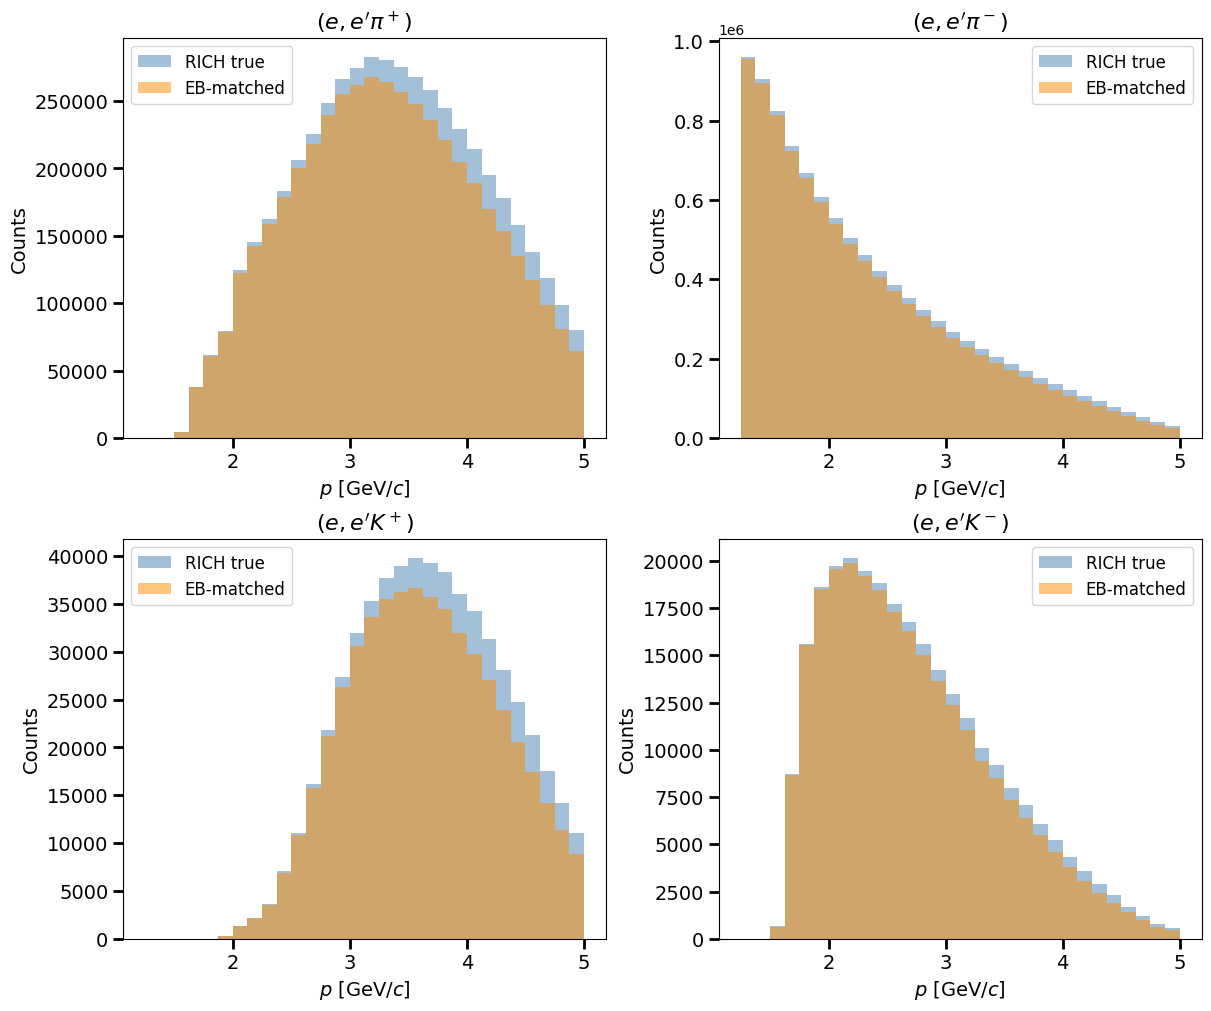

In [165]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), layout="constrained")
#fig.suptitle("Momentum distributions: RICH-true vs EB-identified", size=18)

for ax, sp in zip(axs.flatten(), species):
    h_true = f[f"hP_true_{sp}"]
    h_eb   = f[f"hP_eb_{sp}"]

    edges = h_true.axis().edges()
    centers = 0.5 * (edges[:-1] + edges[1:])
    width = edges[1] - edges[0]

    ax.bar(centers, h_true.values(), width=width, alpha=0.5, label="RICH true",  color="steelblue")
    ax.bar(centers, h_eb.values(),   width=width, alpha=0.5, label="EB-matched", color="darkorange")

    ax.set_title(labels[sp], size=16)
    ax.set_xlabel(r"$p$ [GeV/$c$]", size=14)
    ax.set_ylabel("Counts", size=14)
    ax.legend(fontsize=12)
    style_ax(ax)

plt.savefig("../plotting/analysis_note/kaon_plots/rich_corrections_momentum.png", dpi=150)

## ID Efficiency vs Momentum (with binomial errors)

/var/folders/4d/9x90517x6q3cc4_sz1jrqlj00000gn/T/ipykernel_31453/3544467290.py:21: RuntimeWarning: invalid value encountered in divide
  eps     = np.where(mask, n_eb / n_true, np.nan)


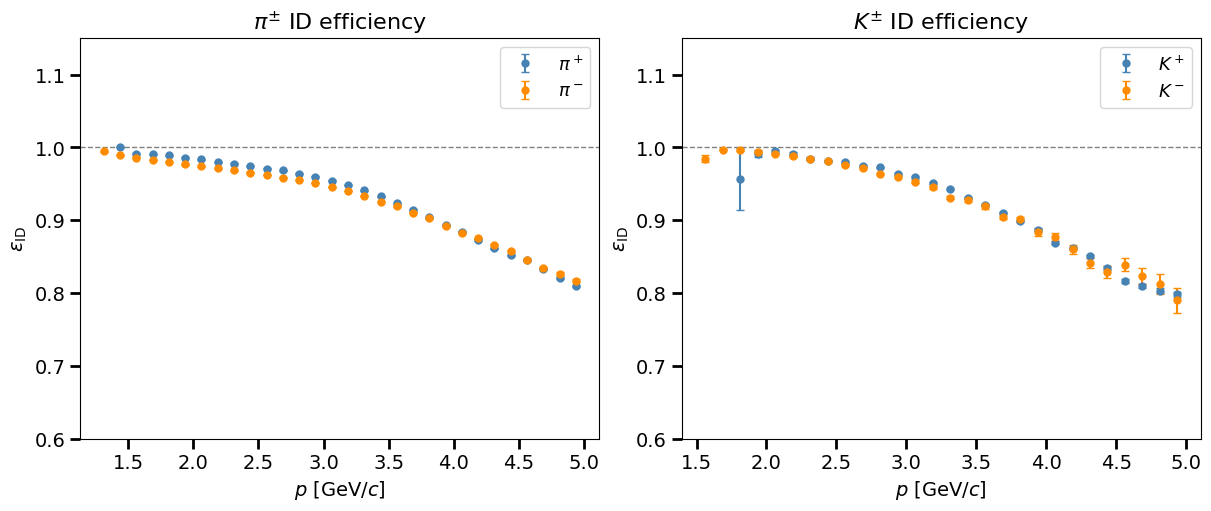

In [166]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
#fig.suptitle("EB ID efficiency vs momentum (binomial errors)", size=18)

groups = [
    (["pip", "pim"], [r"$\pi^+$", r"$\pi^-$"], ["steelblue", "darkorange"], r"$\pi^{\pm}$ ID efficiency"),
    (["kp",  "km"],  [r"$K^+$",  r"$K^-$"],    ["steelblue", "darkorange"], r"$K^{\pm}$ ID efficiency"),
]

for ax, (sps, labs, colors, title) in zip(axs, groups):
    for sp, lab, color in zip(sps, labs, colors):
        h_true = f[f"hP_true_{sp}"]
        h_eb   = f[f"hP_eb_{sp}"]

        edges   = h_true.axis().edges()
        centers = 0.5 * (edges[:-1] + edges[1:])

        n_true = h_true.values()
        n_eb   = h_eb.values()

        mask    = n_true > 0
        eps     = np.where(mask, n_eb / n_true, np.nan)
        eps_err = np.where(mask, np.sqrt(eps * (1 - eps) / n_true), np.nan)

        ax.errorbar(centers, eps, yerr=eps_err, fmt='o', ms=5,
                    color=color, ecolor=color, capsize=3, label=lab)

    ax.axhline(1, linestyle='--', color='grey', linewidth=1)
    ax.set_ylim(0.6, 1.15)
    ax.set_title(title, size=16)
    ax.set_xlabel(r"$p$ [GeV/$c$]", size=14)
    ax.set_ylabel(r"$\epsilon_{\rm ID}$", size=14)
    ax.legend(fontsize=13)
    style_ax(ax)

plt.savefig("../plotting/analysis_note/kaon_plots/rich_corrections_efficiency_1d.png", dpi=150)

## 2D Efficiency: $\theta$ vs $p$

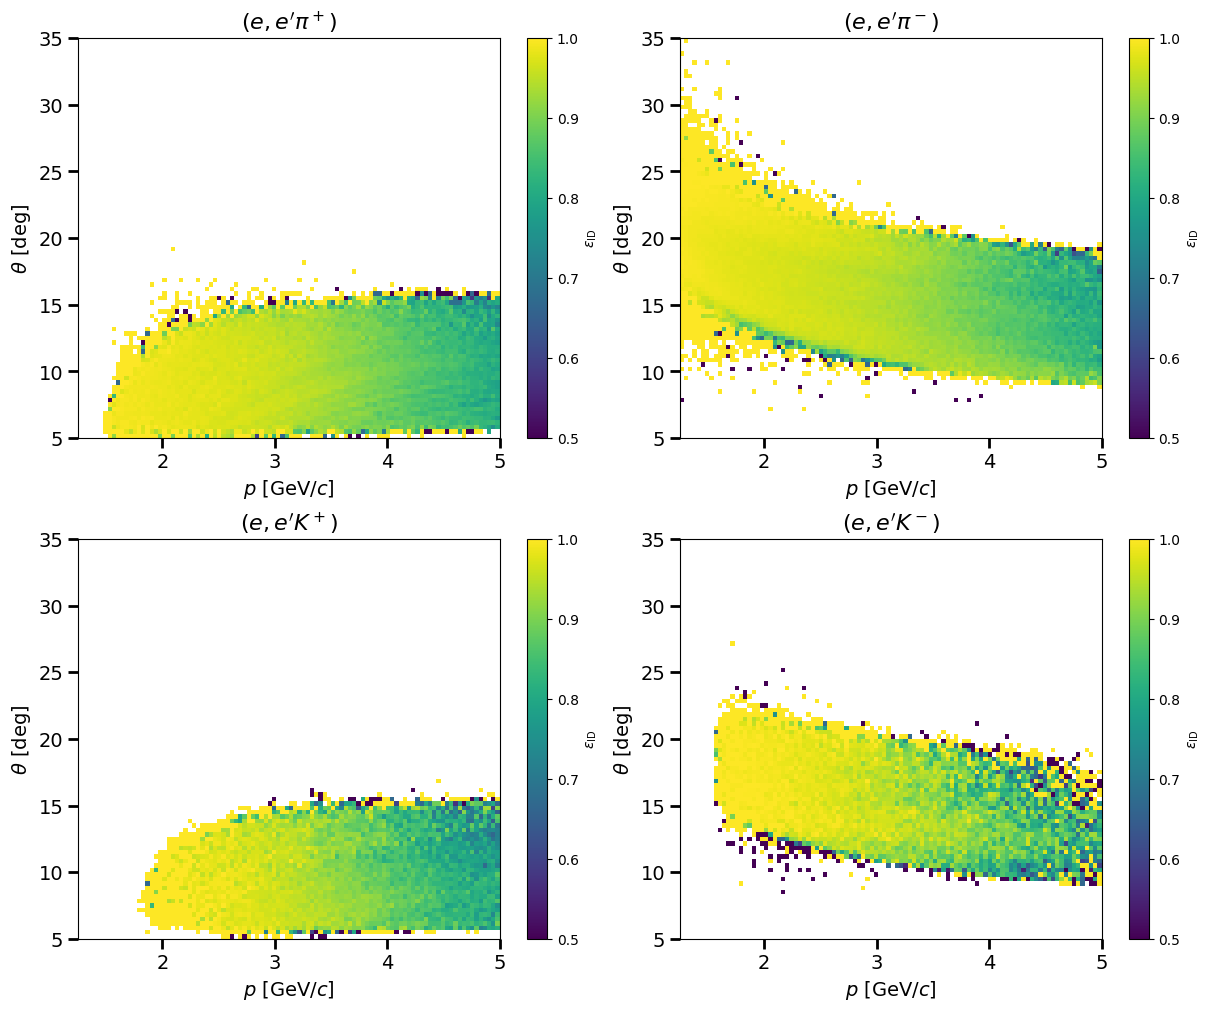

In [167]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), layout="constrained")
#fig.suptitle(r"EB ID efficiency: $\theta$ vs $p$", size=18)

for ax, sp, rsp in zip(axs.flatten(), species, ratio_species):
    h_true = f[f"hTheta_p_true_{sp}"]
    h_eb   = f[f"hTheta_p_eb_{sp}"]

    xedges = h_true.axis(0).edges()
    yedges = h_true.axis(1).edges()

    n_true = h_true.values()
    n_eb   = h_eb.values()

    with np.errstate(invalid='ignore', divide='ignore'):
        eps = np.where(n_true > 0, n_eb / n_true, np.nan)

    mesh = ax.pcolormesh(xedges, yedges, eps.T,
                         cmap='viridis', shading='auto', vmin=0.5, vmax=1)
    fig.colorbar(mesh, ax=ax, label=r"$\epsilon_{\rm ID}$")
    ax.set_title(labels[rsp], size=16)
    ax.set_xlabel(r"$p$ [GeV/$c$]", size=14)
    ax.set_ylabel(r"$\theta$ [deg]", size=14)
    style_ax(ax)

plt.savefig("../plotting/analysis_note/kaon_plots/rich_corrections_efficiency_2d.png", dpi=150)

## $\theta$ vs $p$: EB-matched tracks

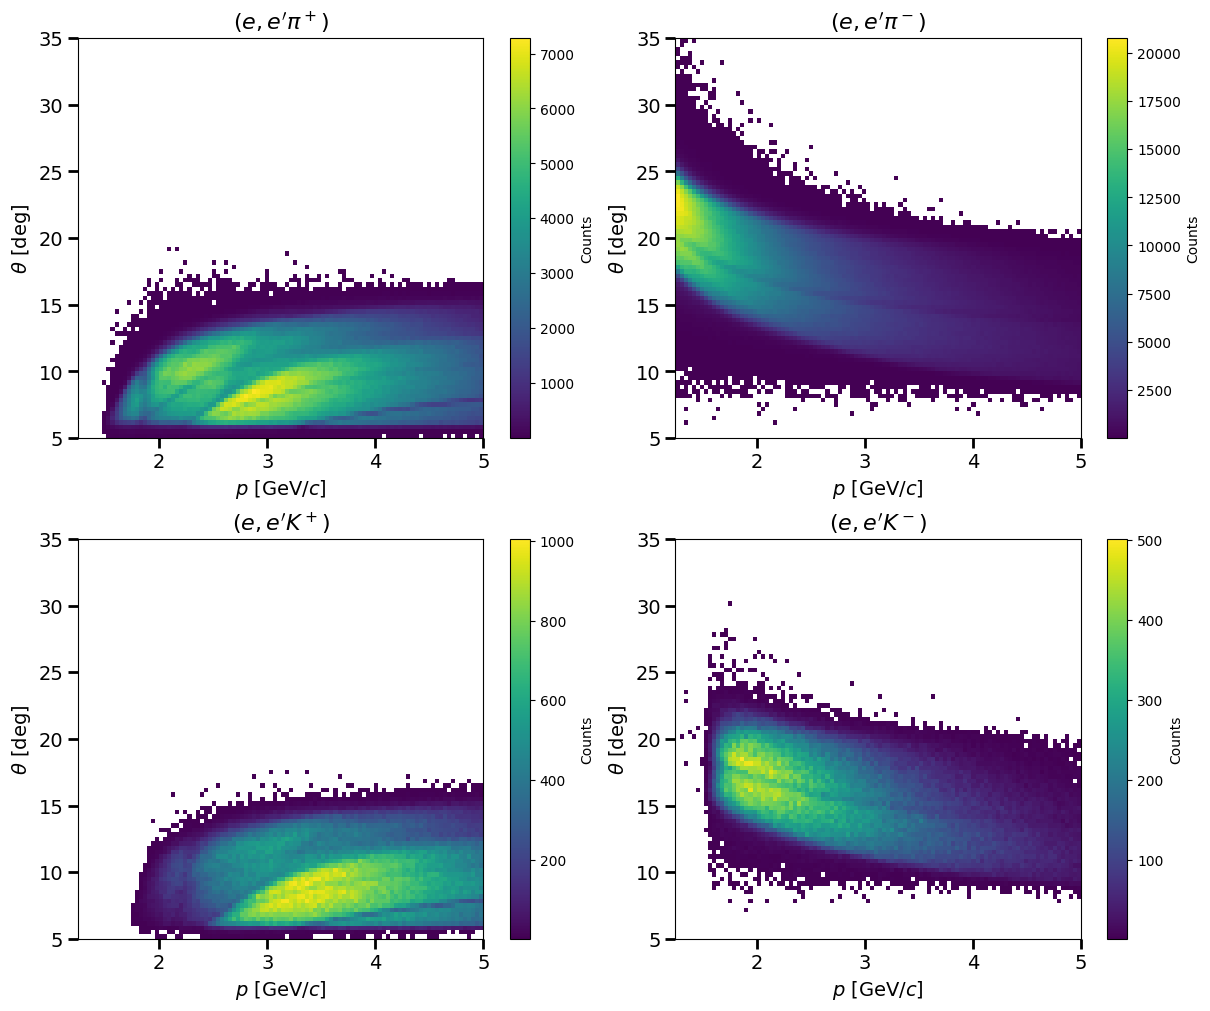

In [174]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), layout="constrained")
#fig.suptitle(r"$\theta$ vs $p$: EB-matched tracks", size=18)

for ax, sp in zip(axs.flatten(), species):
    h = f[f"hTheta_p_eb_{sp}"]
    xedges = h.axis(0).edges()
    yedges = h.axis(1).edges()
    vals = h.values().astype(float)
    vals[vals == 0] = np.nan

    mesh = ax.pcolormesh(xedges, yedges, vals.T,
                         cmap='viridis', shading='auto')#,
                         #norm=mcolors.LogNorm())
    fig.colorbar(mesh, ax=ax, label="Counts")
    ax.set_title(labels[sp], size=16)
    ax.set_xlabel(r"$p$ [GeV/$c$]", size=14)
    ax.set_ylabel(r"$\theta$ [deg]", size=14)
    style_ax(ax)

plt.savefig("../plotting/analysis_note/kaon_plots/rich_theta_p_eb.png", dpi=150)

## RICH Photon Count ($n_{\rm RICH}$) vs Momentum

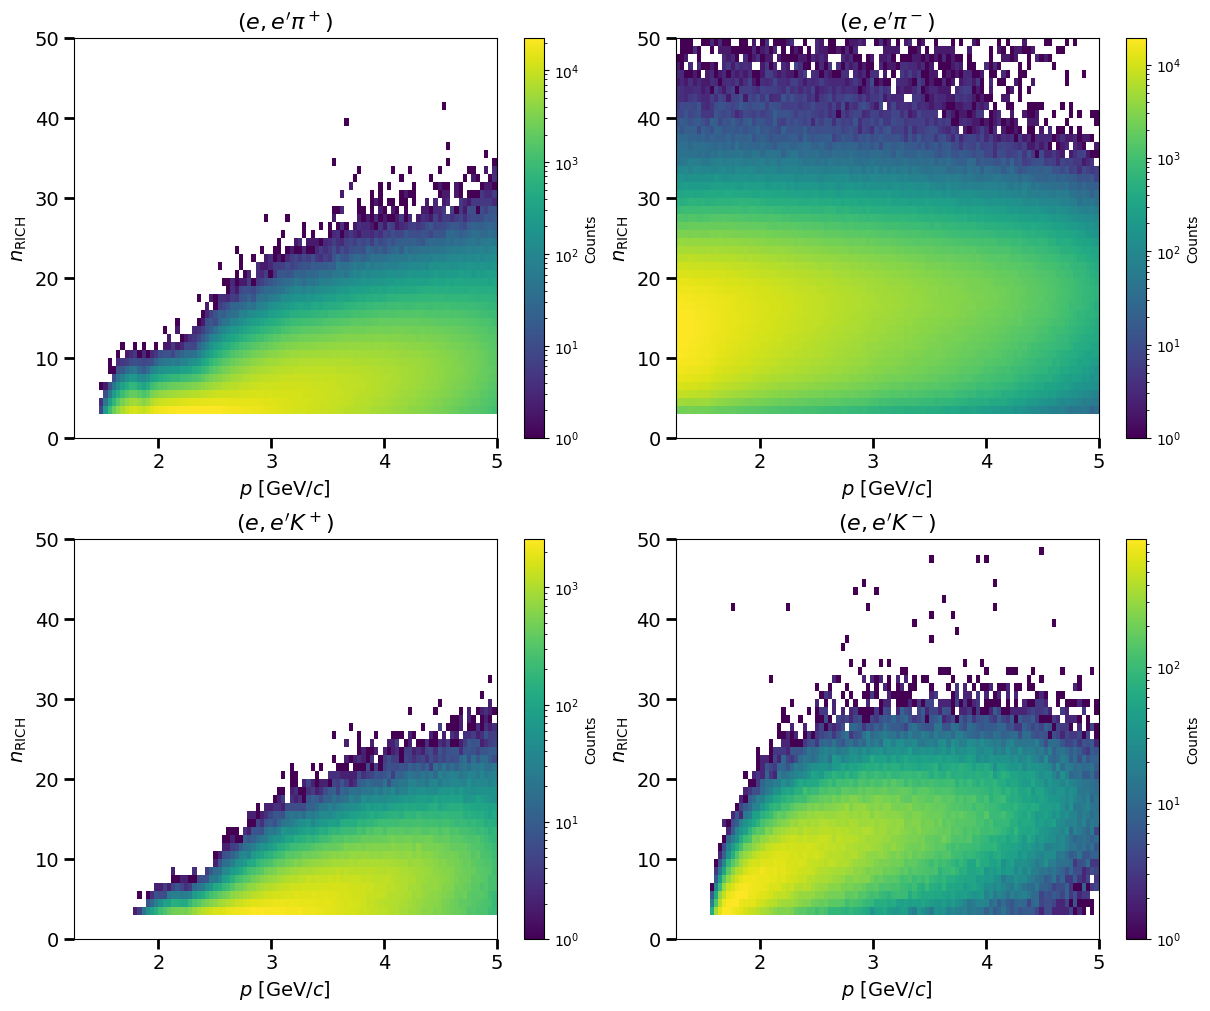

In [169]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), layout="constrained")
#fig.suptitle(r"$n_{\rm RICH}$ vs $p$ (all RICH-true tracks)", size=18)
f0 = uproot.open("../kaonAnalysis/kaonP_0.root")

for ax, sp in zip(axs.flatten(), species):
    h = f[f"hNRICH_p_{sp}"]
    xedges = h.axis(0).edges()
    yedges = h.axis(1).edges()
    vals = h.values().astype(float)
    vals[vals == 0] = np.nan

    mesh = ax.pcolormesh(xedges, yedges, vals.T,
                         cmap='viridis', shading='auto',
                         norm=mcolors.LogNorm())
    fig.colorbar(mesh, ax=ax, label="Counts")
    ax.set_title(labels[sp], size=16)
    ax.set_xlabel(r"$p$ [GeV/$c$]", size=14)
    ax.set_ylabel(r"$n_{\rm RICH}$", size=14)
    style_ax(ax)

#plt.savefig("rich_nphot_p.png", dpi=150)

## RICH Probability vs Momentum

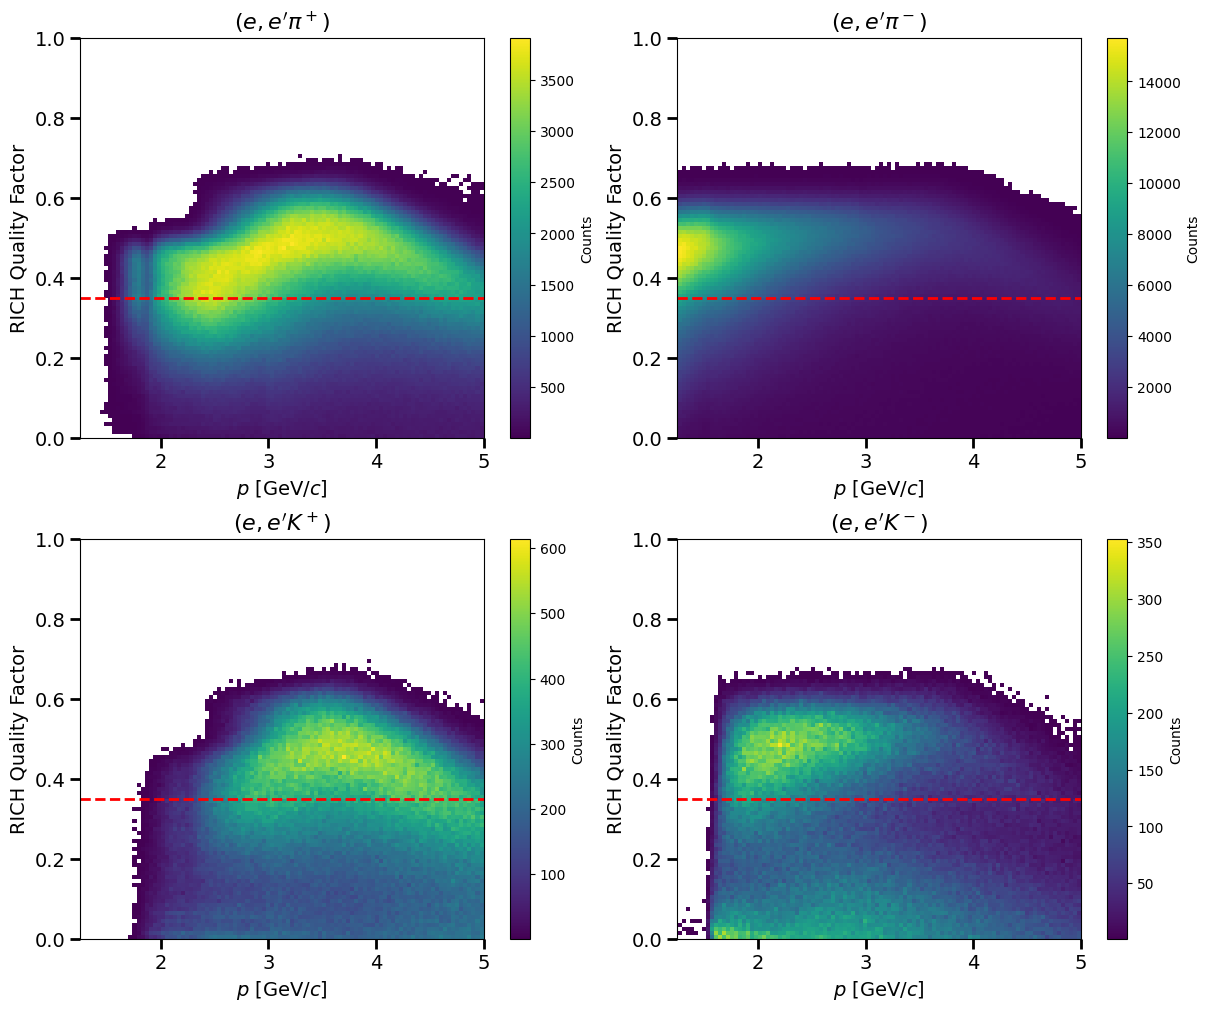

In [170]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), layout="constrained")
#fig.suptitle(r"RICH probability vs $p$ (all RICH-true tracks)", size=18)
f = uproot.open("../kaonAnalysis/kaonP_0.root")

for ax, sp in zip(axs.flatten(), species):
    h = f[f"hProbRICH_p_{sp}"]
    xedges = h.axis(0).edges()
    yedges = h.axis(1).edges()
    vals = h.values().astype(float)
    vals[vals == 0] = np.nan

    mesh = ax.pcolormesh(xedges, yedges, vals.T,
                         cmap='viridis', shading='auto')#,
                         #norm=mcolors.LogNorm())
    fig.colorbar(mesh, ax=ax, label="Counts")
    ax.set_title(labels[sp], size=16)
    ax.set_xlabel(r"$p$ [GeV/$c$]", size=14)
    ax.set_ylabel(r"RICH Quality Factor", size=14)
    style_ax(ax)
    ax.axhline(y=0.35, linestyle='--', color='r', linewidth=2)

plt.savefig("../plotting/analysis_note/kaon_plots/rich_prob_p.png", dpi=150)

## $n_{\rm RICH}$ vs $p$: EB-matched tracks only

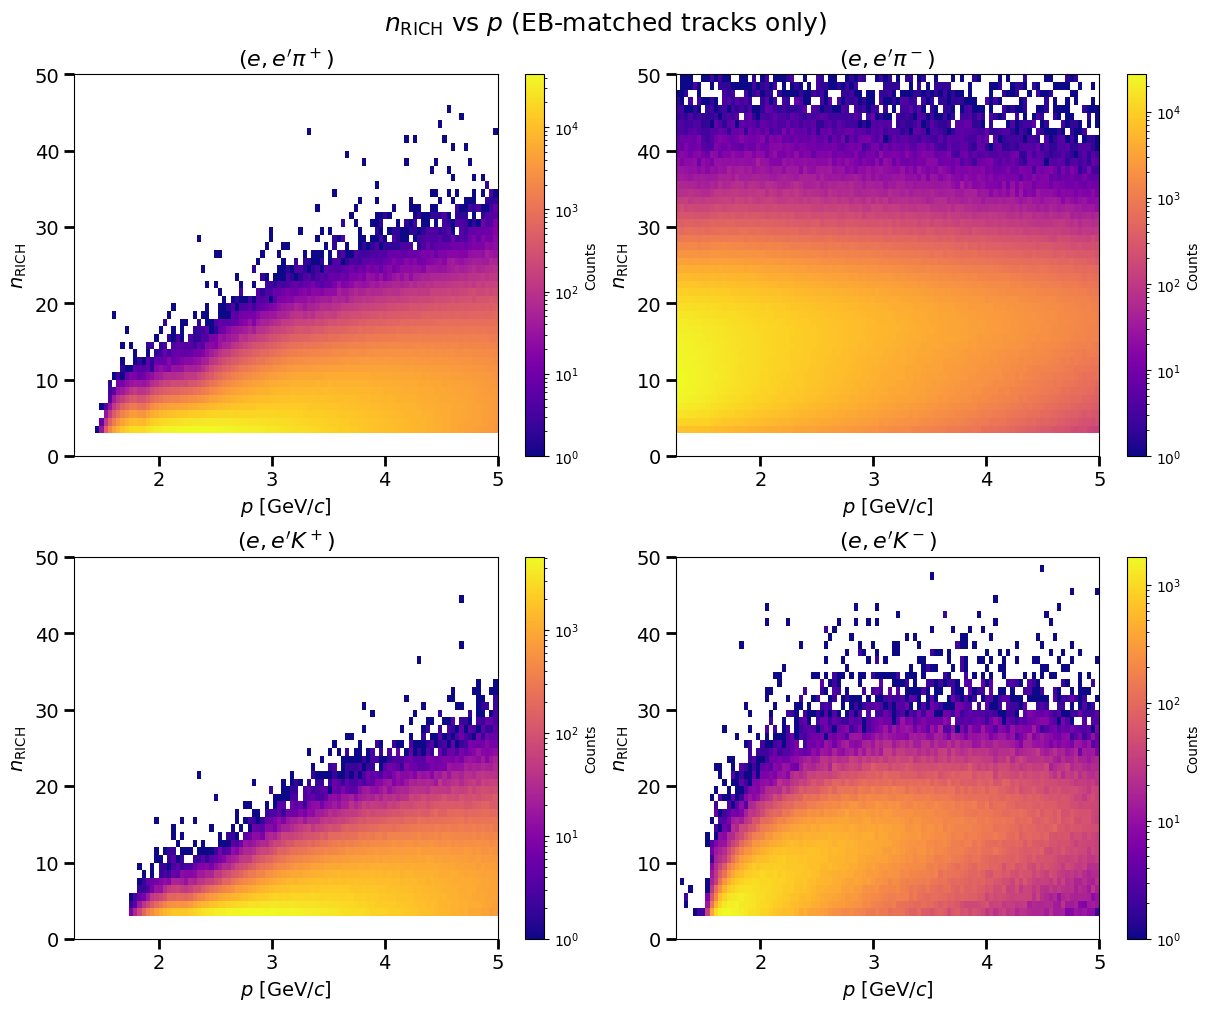

In [171]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), layout="constrained")
fig.suptitle(r"$n_{\rm RICH}$ vs $p$ (EB-matched tracks only)", size=18)

for ax, sp in zip(axs.flatten(), species):
    h = f[f"hNRICH_p_eb_{sp}"]
    xedges = h.axis(0).edges()
    yedges = h.axis(1).edges()
    vals = h.values().astype(float)
    vals[vals == 0] = np.nan

    norm = mcolors.LogNorm() if np.any(np.isfinite(vals)) else None
    mesh = ax.pcolormesh(xedges, yedges, vals.T,
                         cmap='plasma', shading='auto', norm=norm)
    fig.colorbar(mesh, ax=ax, label="Counts")
    ax.set_title(labels[sp], size=16)
    ax.set_xlabel(r"$p$ [GeV/$c$]", size=14)
    ax.set_ylabel(r"$n_{\rm RICH}$", size=14)
    style_ax(ax)

plt.savefig("../plotting/analysis_note/kaon_plots/rich_nphot_p_eb.png", dpi=150)

## ID Efficiency vs Momentum: Multi-file Overlay

## ID Efficiency as a Function of $p$ and Probability Cut

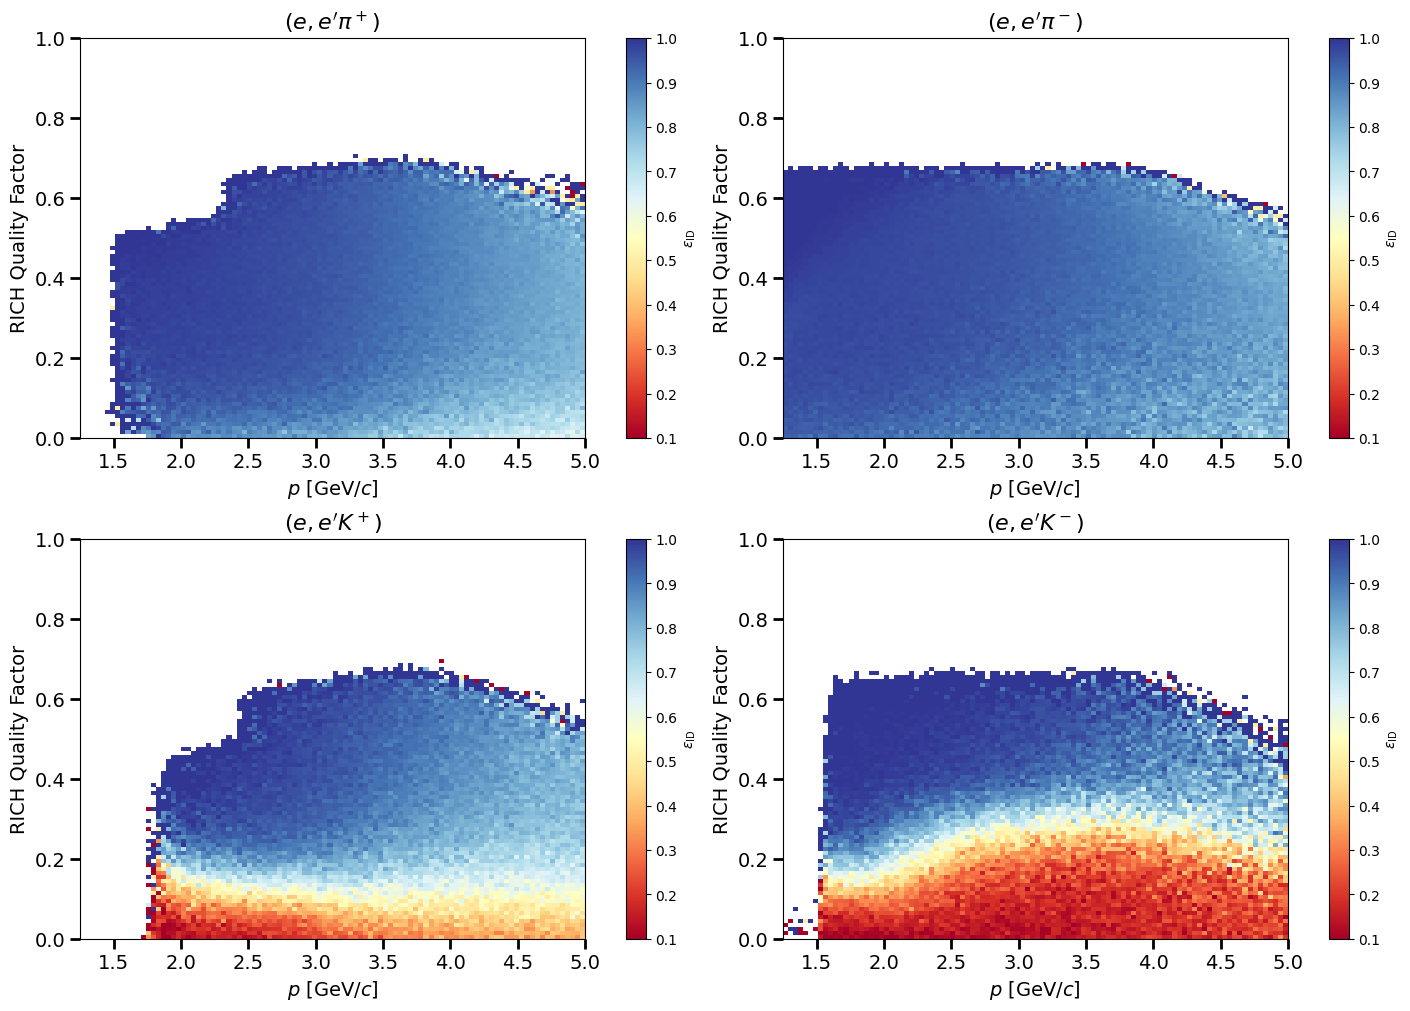

In [172]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10), layout="constrained")
#fig.suptitle(r"ID efficiency vs $p$ and RICH probability", size=18)

f0 = uproot.open("../kaonAnalysis/kaonP_0.root")

for ax, sp in zip(axs.flatten(), species):
    h_true = f0[f"hProbRICH_p_{sp}"]
    h_eb   = f0[f"hProbRICH_p_eb_{sp}"]

    p_edges    = h_true.axis(0).edges()
    prob_edges = h_true.axis(1).edges()

    n_true = h_true.values()   # shape (n_p, n_prob)
    n_eb   = h_eb.values()

    with np.errstate(invalid='ignore', divide='ignore'):
        eps = np.where(n_true > 0, n_eb / n_true, np.nan)

    mesh = ax.pcolormesh(
        p_edges, prob_edges, eps.T,
        cmap='RdYlBu', shading='auto', vmin=0.1, vmax=1.0
    )
    fig.colorbar(mesh, ax=ax, label=r"$\epsilon_{\rm ID}$")
    ax.set_title(labels[sp], size=16)
    ax.set_xlabel(r"$p$ [GeV/$c$]", size=14)
    ax.set_ylabel("RICH Quality Factor", size=14)
    style_ax(ax)

plt.savefig("../plotting/analysis_note/kaon_plots/rich_efficiency_p_vs_prob.png", dpi=150)

/var/folders/4d/9x90517x6q3cc4_sz1jrqlj00000gn/T/ipykernel_31453/2996939550.py:45: RuntimeWarning: invalid value encountered in divide
  eps     = np.where(mask, n_eb / n_true, np.nan)


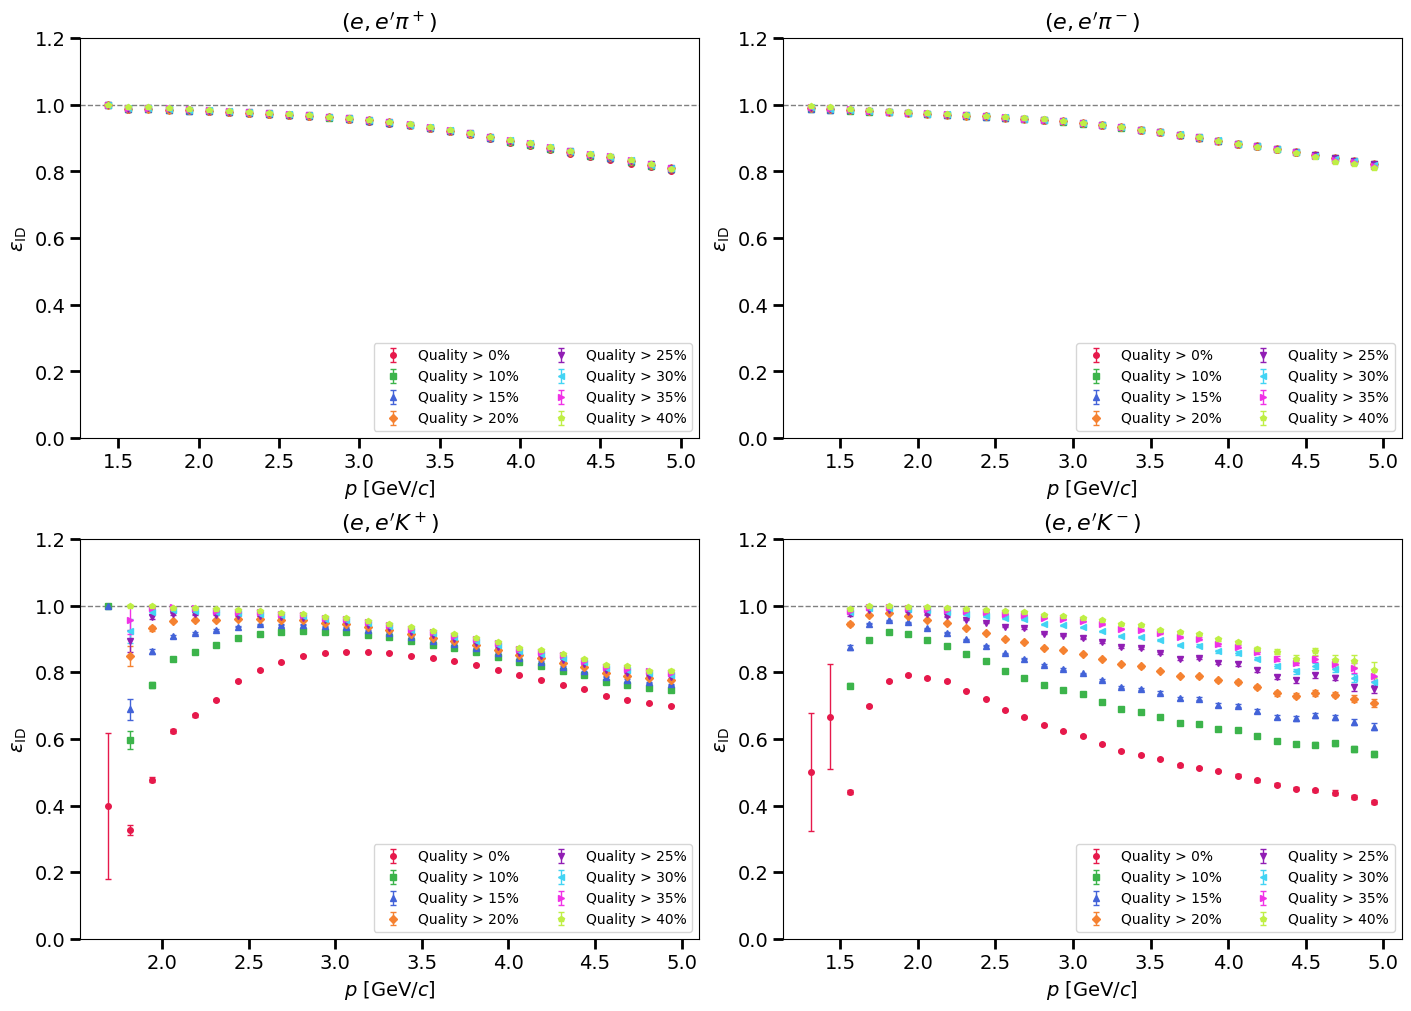

In [173]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Each entry: (file path, legend label)
overlay_files = [
    ("../kaonAnalysis/kaonP_0.root",  "Quality > 0%"),
    ("../kaonAnalysis/kaonP_10.root", "Quality > 10%"),
    ("../kaonAnalysis/kaonP_15.root", "Quality > 15%"),
    ("../kaonAnalysis/kaonP_20.root", "Quality > 20%"),
    ("../kaonAnalysis/kaonP_25.root", "Quality > 25%"),
    ("../kaonAnalysis/kaonP_30.root", "Quality > 30%"),
    ("../kaonAnalysis/kaonP_35.root", "Quality > 35%"),
    ("../kaonAnalysis/kaonP_40.root", "Quality > 40%"),
]

colors_overlay = [
    '#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
    '#42d4f4','#f032e6','#bfef45','#469990','#dcbeff',
]
markers_overlay = ['o','s','^','D','v','<','>','p']

# ── Plot: one 2×2 figure per species ──────────────────────────────────────────
fig, axs = plt.subplots(2, 2, figsize=(14, 10), layout="constrained")
#fig.suptitle("EB ID efficiency vs $p$: multi-file overlay", size=18)

for ax, sp in zip(axs.flatten(), species):
    for idx, (fpath, flabel) in enumerate(overlay_files):
        try:
            fi = uproot.open(fpath)
        except Exception:
            print(f"Could not open {fpath}, skipping")
            continue

        if f"hP_true_{sp}" not in fi or f"hP_eb_{sp}" not in fi:
            continue

        h_true = fi[f"hP_true_{sp}"]
        h_eb   = fi[f"hP_eb_{sp}"]

        edges   = h_true.axis().edges()
        centers = 0.5 * (edges[:-1] + edges[1:])

        n_true = h_true.values()
        n_eb   = h_eb.values()

        mask    = n_true > 0
        eps     = np.where(mask, n_eb / n_true, np.nan)
        eps_err = np.where(mask, np.sqrt(np.clip(eps * (1 - eps), 0, None) / n_true), np.nan)

        color  = colors_overlay[idx % len(colors_overlay)]
        marker = markers_overlay[idx % len(markers_overlay)]

        ax.errorbar(centers, eps, yerr=eps_err,
                    fmt=marker, ms=4, color=color, ecolor=color,
                    capsize=2, lw=1, capthick=1, label=flabel)

    ax.axhline(1, linestyle='--', color='grey', linewidth=1)
    ax.set_ylim(0, 1.2)
    ax.set_title(labels[sp], size=16)
    ax.set_xlabel(r"$p$ [GeV/$c$]", size=14)
    ax.set_ylabel(r"$\epsilon_{\rm ID}$", size=14)
    ax.legend(fontsize=10, loc='lower right', ncol=2)
    style_ax(ax)

plt.savefig("../plotting/analysis_note/kaon_plots/rich_efficiency_overlay.png", dpi=150)

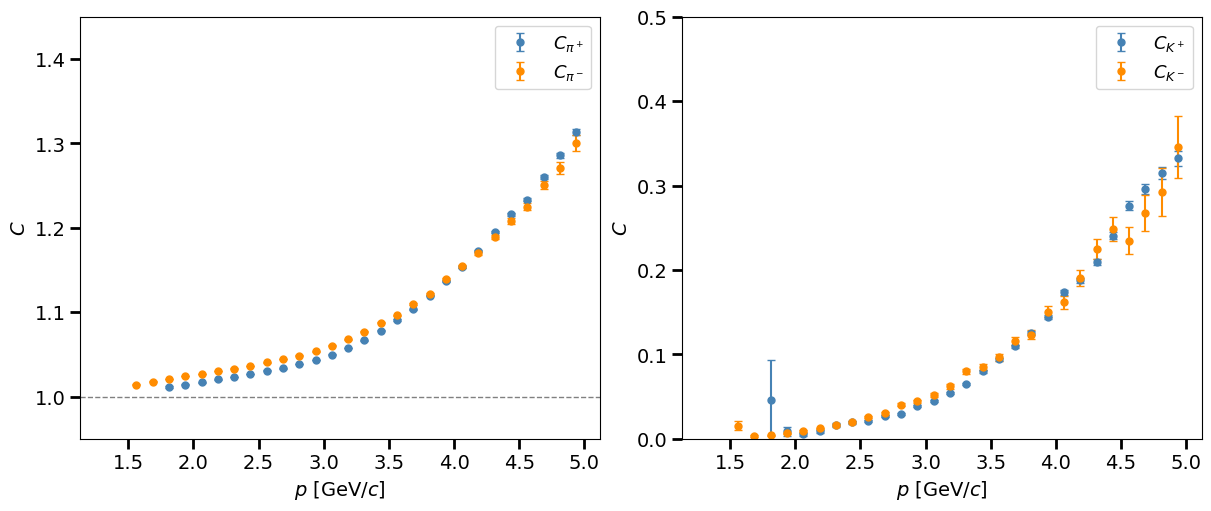

In [186]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
#fig.suptitle("EB ID efficiency vs momentum (binomial errors)", size=18)
f = uproot.open("../data/correctionFiles/corrections_misid_AN.root")

groups = [
    (["pip", "pim"], [r"$C_{\pi^+}$", r"$C_{\pi^-}$"], ["steelblue", "darkorange"], r"$\pi^{\pm}$ ID efficiency", (0.95, 1.45)),
    (["kp",  "km"],  [r"$C_{K^+}$",  r"$C_{K^-}$"],    ["steelblue", "darkorange"], r"$K^{\pm}$ ID efficiency",   (0.0, .5)),
]

for ax, (sps, labs, colors, title, ylim) in zip(axs, groups):
    for sp, lab, color in zip(sps, labs, colors):
        h_true = f[f"hFactor_{sp}"]
        #h_eb   = f[f"hP_eb_{sp}"]

        edges   = h_true.axis().edges()
        centers = 0.5 * (edges[:-1] + edges[1:])

        n_true = h_true.values()
        err = h_true.errors()
        #n_eb   = h_eb.values()

        mask    = n_true > 0
        #eps     = np.where(mask, n_true, np.nan)
        #eps_err = np.where(mask, np.sqrt(eps * (1 - eps) / n_true), np.nan)

        ax.errorbar(centers, n_true, yerr=err, fmt='o', ms=5,
                    color=color, ecolor=color, capsize=3, label=lab)

    ax.axhline(1, linestyle='--', color='grey', linewidth=1)
    ax.set_ylim(*ylim)
    #ax.set_title(title, size=16)
    ax.set_xlabel(r"$p$ [GeV/$c$]", size=14)
    ax.set_ylabel(r"$C$", size=14)
    ax.legend(fontsize=13)
    style_ax(ax)

plt.savefig("../plotting/analysis_note/kaon_plots/correction_factors.png", dpi=150)

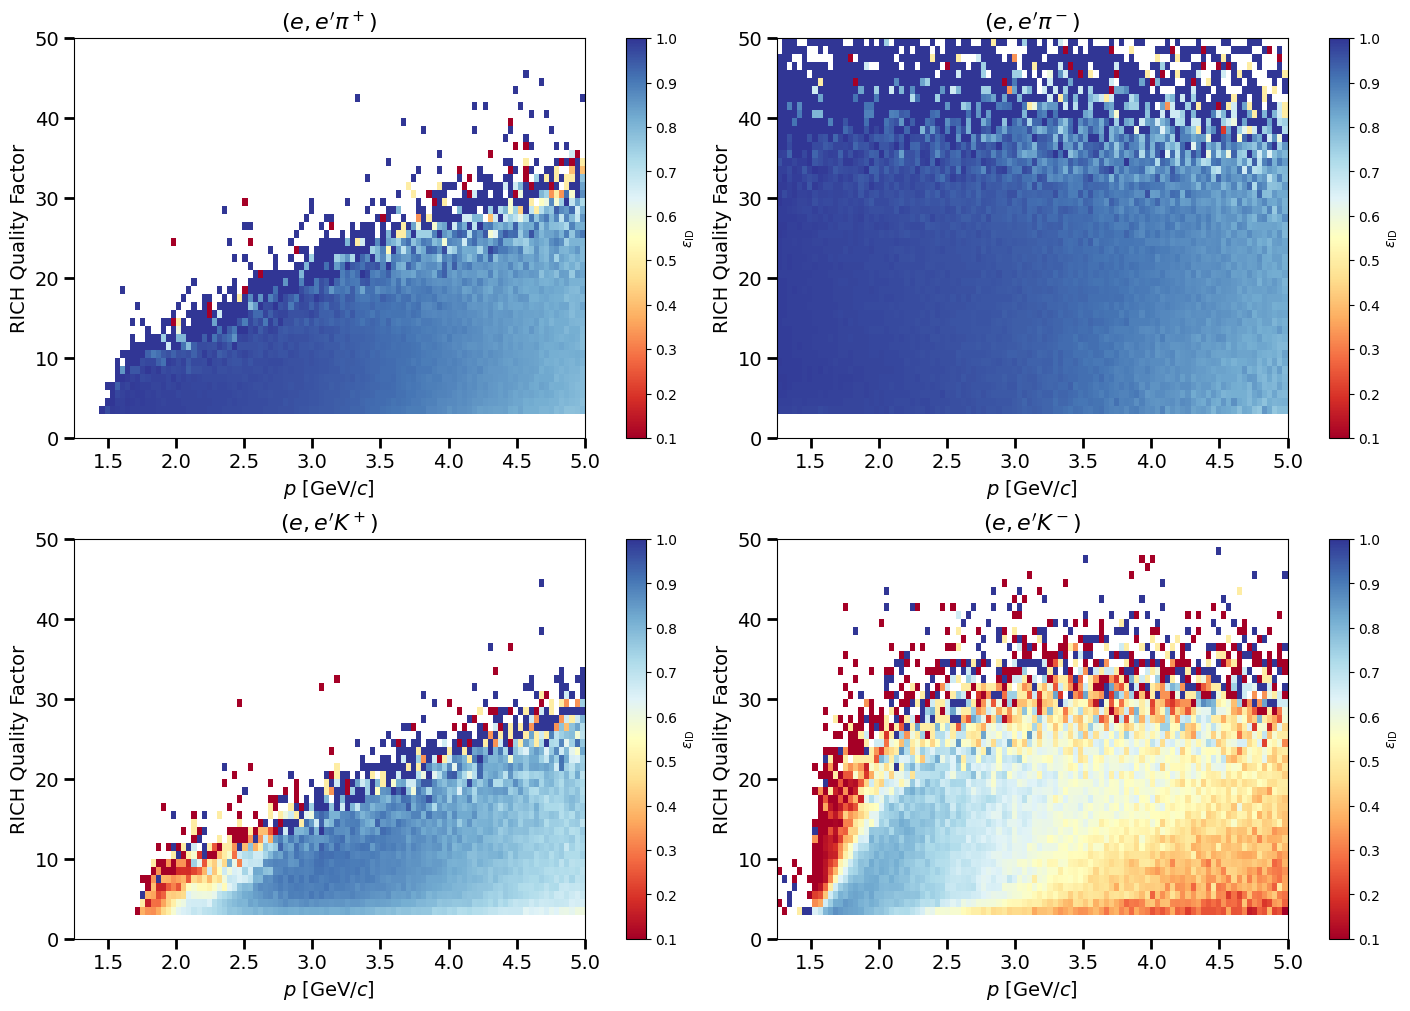

In [187]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10), layout="constrained")
#fig.suptitle(r"ID efficiency vs $p$ and RICH probability", size=18)

f0 = uproot.open("../kaonAnalysis/kaonP_0.root")

for ax, sp in zip(axs.flatten(), species):
    h_true = f0[f"hNRICH_p_{sp}"]
    h_eb   = f0[f"hNRICH_p_eb_{sp}"]

    p_edges    = h_true.axis(0).edges()
    prob_edges = h_true.axis(1).edges()

    n_true = h_true.values()   # shape (n_p, n_prob)
    n_eb   = h_eb.values()

    with np.errstate(invalid='ignore', divide='ignore'):
        eps = np.where(n_true > 0, n_eb / n_true, np.nan)

    mesh = ax.pcolormesh(
        p_edges, prob_edges, eps.T,
        cmap='RdYlBu', shading='auto', vmin=0.1, vmax=1.0
    )
    fig.colorbar(mesh, ax=ax, label=r"$\epsilon_{\rm ID}$")
    ax.set_title(labels[sp], size=16)
    ax.set_xlabel(r"$p$ [GeV/$c$]", size=14)
    ax.set_ylabel("RICH Quality Factor", size=14)
    style_ax(ax)

plt.savefig("../plotting/analysis_note/kaon_plots/rich_efficiency_p_vs_prob.png", dpi=150)

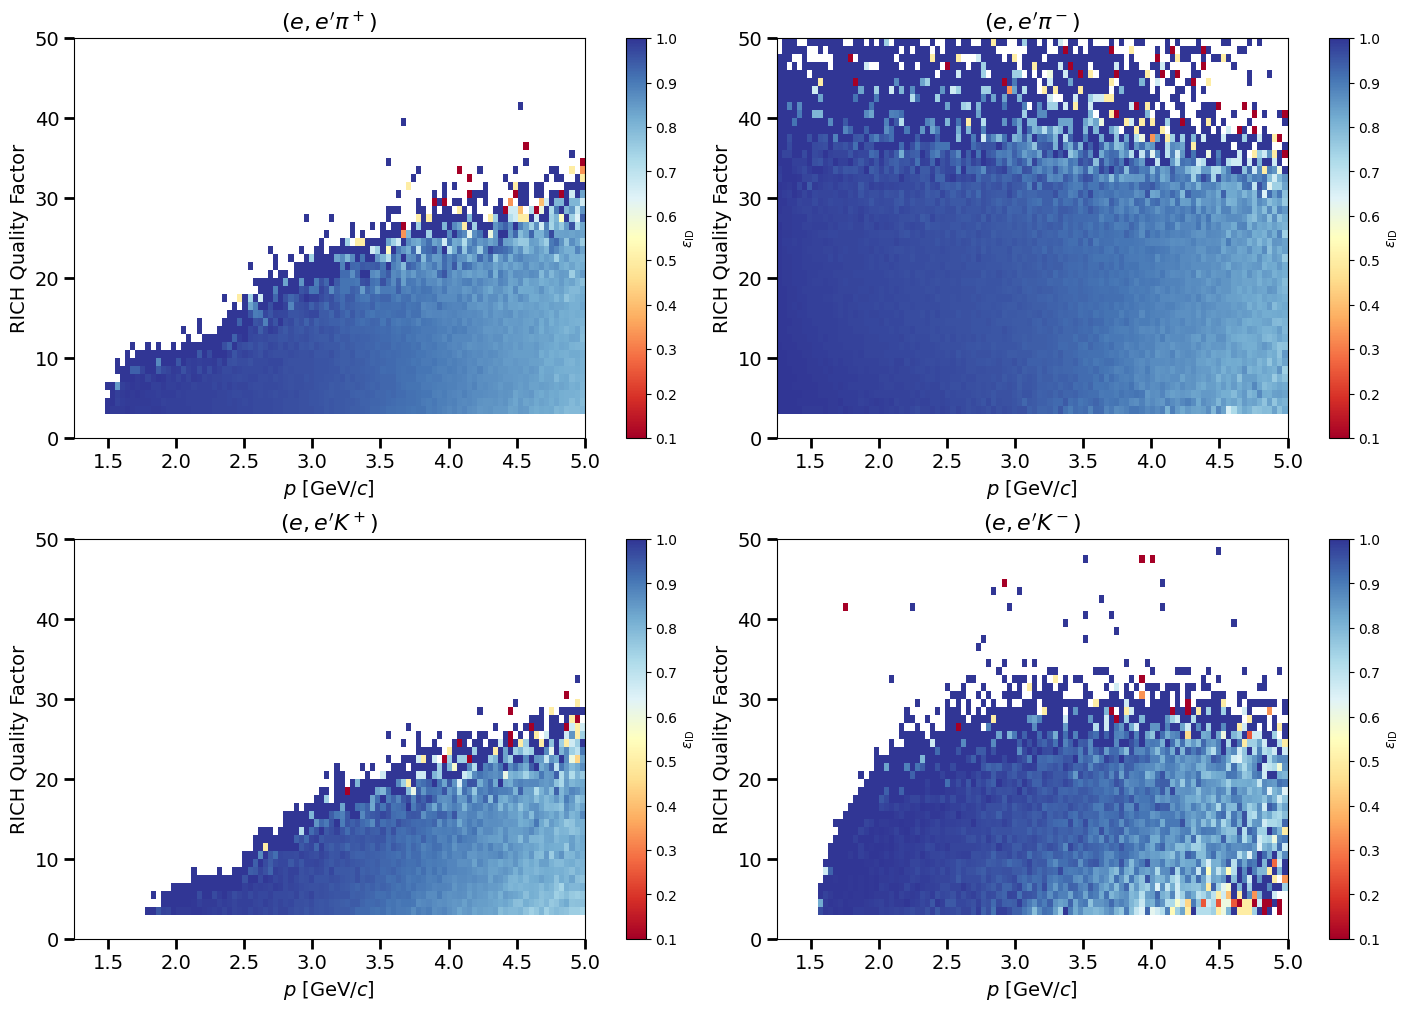

In [188]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10), layout="constrained")
#fig.suptitle(r"ID efficiency vs $p$ and RICH probability", size=18)

f0 = uproot.open("../kaonAnalysis/kaonP_35.root")

for ax, sp in zip(axs.flatten(), species):
    h_true = f0[f"hNRICH_p_{sp}"]
    h_eb   = f0[f"hNRICH_p_eb_{sp}"]

    p_edges    = h_true.axis(0).edges()
    prob_edges = h_true.axis(1).edges()

    n_true = h_true.values()   # shape (n_p, n_prob)
    n_eb   = h_eb.values()

    with np.errstate(invalid='ignore', divide='ignore'):
        eps = np.where(n_true > 0, n_eb / n_true, np.nan)

    mesh = ax.pcolormesh(
        p_edges, prob_edges, eps.T,
        cmap='RdYlBu', shading='auto', vmin=0.1, vmax=1.0
    )
    fig.colorbar(mesh, ax=ax, label=r"$\epsilon_{\rm ID}$")
    ax.set_title(labels[sp], size=16)
    ax.set_xlabel(r"$p$ [GeV/$c$]", size=14)
    ax.set_ylabel("RICH Quality Factor", size=14)
    style_ax(ax)

plt.savefig("../plotting/analysis_note/kaon_plots/rich_efficiency_p_vs_prob.png", dpi=150)